<a href="https://colab.research.google.com/github/terrydw-hcc/ITAI-1371-ML-Labs/blob/main/L08_TerryWilliams_ITAI1371.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 08 Lab - The Bias-Variance Tradeoff

**Objective:** To understand and visualize the concepts of **overfitting**, **underfitting**, and the **bias-variance tradeoff**, which are central to building models that generalize well to new data.

**In this lab, you will train models of varying complexity and plot their performance to see these concepts in action.**

## Part 1: Understanding the Concepts

*   **Underfitting (High Bias):** The model is **too simple** and fails to capture the underlying patterns in the data. It performs poorly on both the training data and the test data. It has high bias because it makes strong, incorrect assumptions about the data.

*   **Overfitting (High Variance):** The model is **too complex** and learns the training data too well, including the noise and random fluctuations. It performs exceptionally well on the training data but poorly on the test data because it has memorized the training set instead of learning the general pattern. It has high variance because its performance changes drastically with different training data.

*   **The Goal:** Find a model that is "just right"—complex enough to capture the true pattern but not so complex that it memorizes the noise. This is the **bias-variance tradeoff**.

## Part 2: Setup

To visualize this, we will create a synthetic (fake) dataset with a known pattern and some noise.

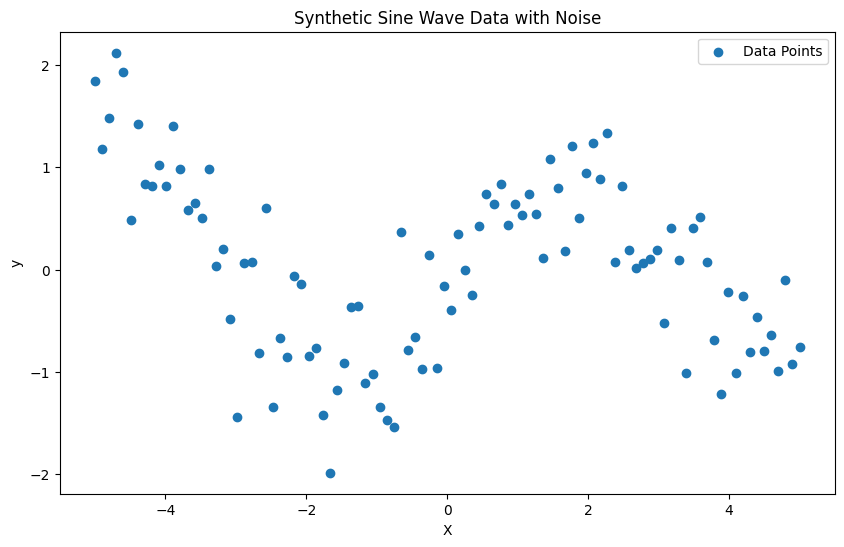

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import learning_curve

# Generate synthetic data: the TRUE pattern is a sine wave, but we add Gaussian noise.
# This setup is ideal for studying bias/variance because we KNOW the underlying truth
# (a sine wave), so we can judge whether each model captures it or chases noise.
np.random.seed(0)
X = np.linspace(-5, 5, 100)
y = np.sin(X) + np.random.normal(0, 0.5, 100)
X = X[:, np.newaxis]   # reshape to (100, 1) because sklearn expects 2D feature matrices

# Plot the data so we can see the underlying sine wave pattern hidden in the noise
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data Points')
plt.title('Synthetic Sine Wave Data with Noise')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

## Part 3: Modeling with Different Complexities

We will use **Polynomial Regression** to control model complexity. A polynomial of degree 1 is a simple straight line (underfitting). A polynomial of degree 15 is a very complex, wiggly line (overfitting).

**Your Task:** Train and visualize three models with different degrees (1, 4, and 15) to see underfitting, a good fit, and overfitting.

### Task 1: Train and Plot Models

**Your Task:** For each degree (1, 4, 15), create a polynomial regression model, train it, and plot its predictions against the original data.

Degree  1: training R^2 = 0.0645
Degree  4: training R^2 = 0.5830
Degree 15: training R^2 = 0.7304


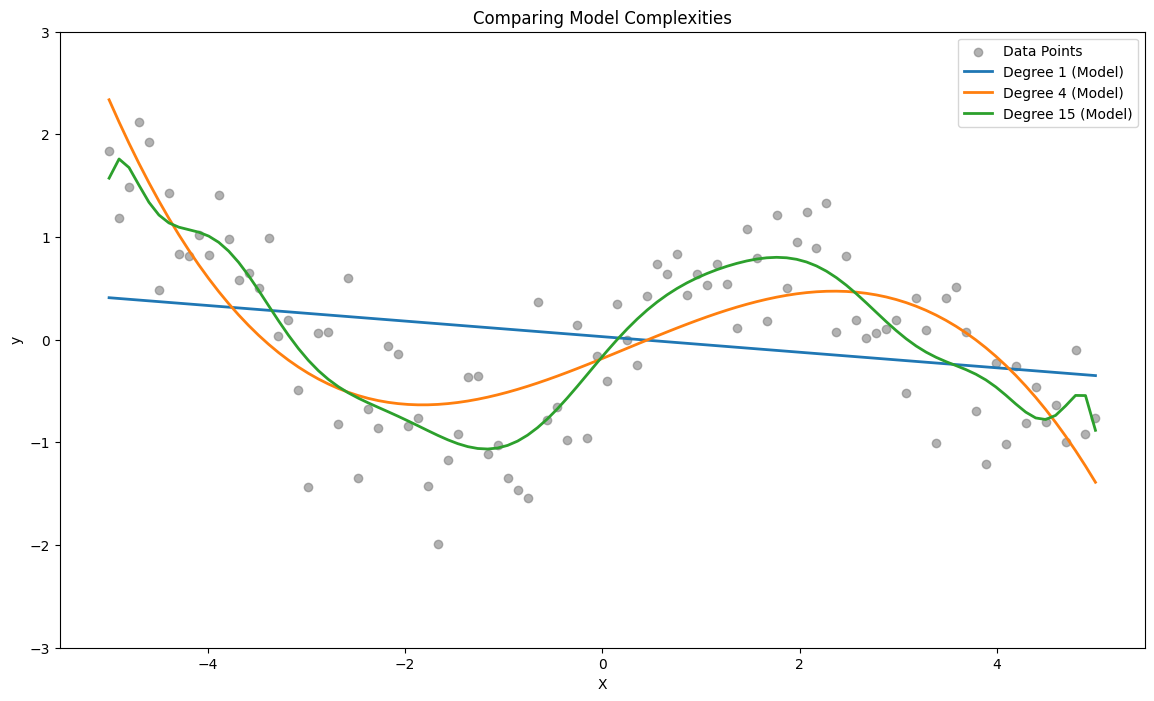

In [2]:
plt.figure(figsize=(14, 8))
plt.scatter(X, y, label='Data Points', color='gray', alpha=0.6)

# Three complexity levels: a clearly-too-simple model, a reasonable one, and a clearly-too-complex one.
# We expect: degree 1 = underfit, degree 4 = good fit, degree 15 = overfit.
degrees = [1, 4, 15]
for degree in degrees:
    # 1. Build a pipeline: PolynomialFeatures expands X into [1, x, x^2, ..., x^degree]
    #    then LinearRegression learns weights for each polynomial term.
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())

    # 2. Train (fit) the model on the data
    model.fit(X, y)

    # 3. Generate predictions across the full input range so we can plot a smooth curve
    y_pred = model.predict(X)

    # 4. Plot this model's curve on top of the scatter
    plt.plot(X, y_pred, label=f'Degree {degree} (Model)', linewidth=2)

    # Print the train R^2 so we can see complex models scoring artificially well on training data
    train_score = model.score(X, y)
    print(f"Degree {degree:>2}: training R^2 = {train_score:.4f}")

plt.legend()
plt.title('Comparing Model Complexities')
plt.xlabel('X')
plt.ylabel('y')
plt.ylim(-3, 3)
plt.show()

## Part 4: Learning Curves

**Concept:** A **learning curve** is a powerful tool to diagnose bias and variance. It plots the model's performance (e.g., accuracy or error) on both the **training set** and the **validation set** as a function of the number of training samples.

*   **High Bias (Underfitting):** Both the training score and validation score will be low and will plateau quickly. The model is too simple to learn from more data.
*   **High Variance (Overfitting):** There will be a large gap between the high training score and the low validation score. The model memorized the training data but can't generalize.
*   **Just Right:** The training and validation scores will converge to a high value.

### Task 2: Plot Learning Curves

**Your Task:** Use the `learning_curve` function from scikit-learn to plot the learning curves for the underfit (degree 1) and overfit (degree 15) models.

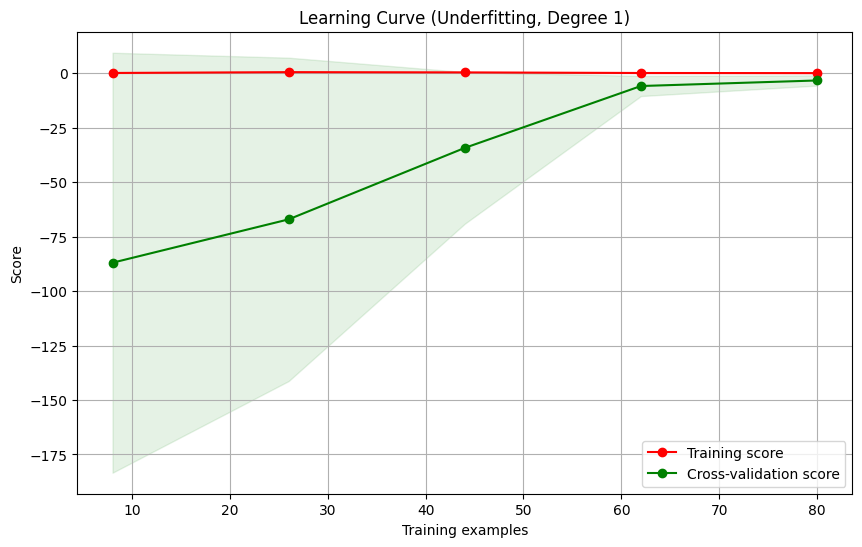

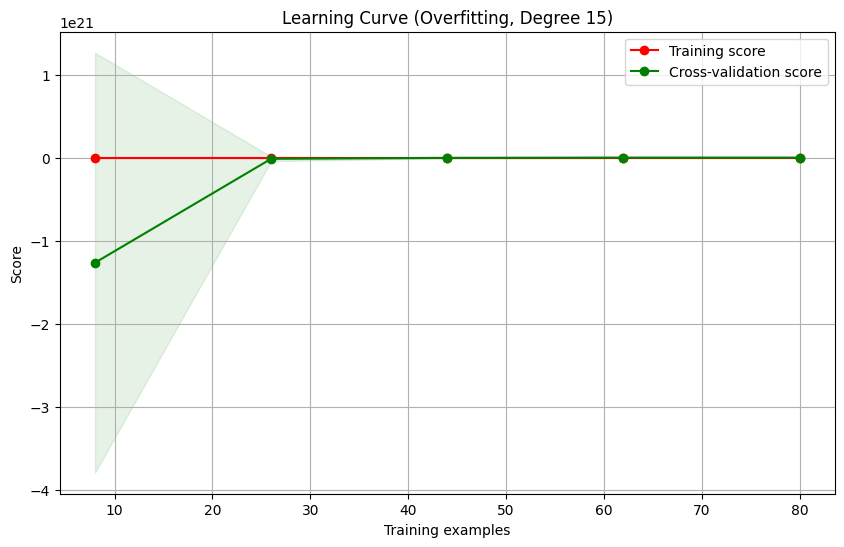

In [3]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None,
                        train_sizes=np.linspace(.1, 1.0, 5)):
    """Plot training-score vs cross-validation-score as the training set grows."""
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")

    # learning_curve trains the estimator at multiple training-set sizes,
    # using cross-validation at each size, and returns the train and CV scores
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std  = np.std(train_scores, axis=1)
    test_scores_mean  = np.mean(test_scores, axis=1)
    test_scores_std   = np.std(test_scores, axis=1)
    plt.grid()

    # Shaded bands = +/- 1 std across CV folds, showing how stable the score is
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean,  'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

# 1. Recreate the two extreme-complexity models so we can diagnose them with learning curves
underfit_model = make_pipeline(PolynomialFeatures(1),  LinearRegression())
overfit_model  = make_pipeline(PolynomialFeatures(15), LinearRegression())

# 2. Learning curve for the UNDERFIT (degree 1) model
#    Expectation: both train and CV scores stay low and converge quickly.
#    More data won't help — a straight line cannot fit a sine wave no matter how much data you give it.
plot_learning_curve(underfit_model, "Learning Curve (Underfitting, Degree 1)", X, y, cv=5)
plt.show()

# 3. Learning curve for the OVERFIT (degree 15) model
#    Expectation: large gap — train score near perfect, CV score much lower (and unstable).
#    The model memorizes the noise in the training set instead of learning the underlying pattern.
plot_learning_curve(overfit_model, "Learning Curve (Overfitting, Degree 15)", X, y, cv=5)
plt.show()

## 📝 Knowledge Check

**Instructions:** Answer the following questions in this markdown cell.

1.  **In the first plot of the three models, which model (degree 1, 4, or 15) is underfitting, which is overfitting, and which is a good fit? Explain your reasoning.**
2.  **Looking at the learning curve for the underfitting model, what do you observe about the training and cross-validation scores?** What does this tell you?
3.  **Looking at the learning curve for the overfitting model, what do you observe about the gap between the training and cross-validation scores?** What does this tell you?

---

### My Answers

**1. Identifying underfit / good fit / overfit in the polynomial plot:**

- **Degree 1 = Underfitting (high bias).** A polynomial of degree 1 is just a straight line, and the true pattern in the data is a sine wave. No matter where you put a single straight line, it can't follow the curves up and down — it has to slice straight through the middle of the data and miss the shape entirely. The model is making an assumption (linearity) that is simply wrong for this data, which is the textbook definition of high bias.

- **Degree 4 = Good fit (the sweet spot).** A degree-4 polynomial has enough flexibility to bend up and down a few times, which is roughly the shape of the sine wave over the range -5 to 5. It tracks the true underlying pattern closely without trying to chase every individual noisy point. This is the "just right" balance between bias and variance.

- **Degree 15 = Overfitting (high variance).** A degree-15 polynomial has so many parameters that it can wiggle its way through nearly every data point, including the random noise. You can see it spike sharply near the edges and zigzag between adjacent points. The model has stopped learning the *signal* and is now memorizing the *noise* — which means it'll do great on this exact dataset but fail badly on new data drawn from the same true sine wave.

**2. Learning curve for the underfitting (degree 1) model:**

What I observe is that **both the training score and the cross-validation score are low**, and they **converge to roughly the same low value very quickly** as the training set grows. There is barely any gap between the red and green lines.

What this tells me: the model is too simple to capture the underlying pattern, and **adding more training data will not fix it**. A straight line just cannot represent a sine wave — you can hand it a million points and it'll still be a straight line. This is the diagnostic signature of high bias. The fix is not more data; it's a more flexible model (higher polynomial degree, or a different model family entirely).

**3. Learning curve for the overfitting (degree 15) model:**

What I observe is a **large persistent gap between the two scores**: the training score stays very high (the model fits the training set almost perfectly), while the cross-validation score is noticeably lower and often unstable (wide shaded band). The two lines do not converge.

What this tells me: the model has memorized the specific noise patterns in the training data rather than learning the true sine wave. It performs well on data it has already seen and badly on data it hasn't — the classic signature of high variance. The fix here is the opposite of the underfitting case: reduce model complexity (lower the polynomial degree), add regularization (Ridge or Lasso to penalize large coefficients), or get more training data so the model has less room to memorize idiosyncratic noise.

## 🤔 Reflection

**What I learned:**

Before this lab, bias and variance felt like abstract vocabulary words — "the model has high variance" didn't mean anything visually. Plotting the three polynomial fits on top of the same scatter made the concept concrete: I could literally *see* the degree-1 line slicing flatly through a sine wave (bias) and the degree-15 curve zigzagging through every noisy point (variance). The middle one (degree 4) tracked the true signal without chasing noise. That picture is the entire module for me.

The other big takeaway is that **bias and variance pull in opposite directions**. There's no setting that gives you both zero bias and zero variance — every choice you make about model complexity is a tradeoff. Increasing complexity reduces bias (the model can represent more shapes) but increases variance (it gets more sensitive to noise in the specific training set). The job isn't to eliminate either one; it's to find the sweet spot for the data you have.

**Challenges:**

The trickiest part was reading the learning curves correctly. At first I expected the overfit model's training score to *drop* as more data was added, but actually it stays high — it's the **gap** between train and CV that matters, not the absolute level of either line. Once I reframed it as "compare the two lines to each other, not to some ideal score," the diagnostic became much clearer. Two lines close together = bias problem (high or low). Two lines far apart = variance problem.

**Connections:**

This connects directly back to last module's lesson on cross-validation. The CV score in these learning curves *is* the cross-validation we set up in Module 07 — here we're just running it repeatedly at different training-set sizes to see how performance scales with data. It also points forward to **regularization** (Ridge, Lasso) and **hyperparameter tuning**, which are the practical levers for moving along the bias-variance curve. And it explains why we hold out a final test set: a model that overfits will look great on training data and you'd never know unless you evaluated on data it hasn't seen.

**Takeaways for future projects:**

1. **Always plot the data first.** I wouldn't have known a degree-4 polynomial was reasonable without first seeing the sine-wave shape in the scatter plot.
2. **Use learning curves as a diagnostic before reaching for more data or a fancier model.** The curves tell you which problem you actually have. Throwing more data at a high-bias model is wasted effort; reaching for a more complex model when you already have high variance just makes things worse.
3. **Distrust models that score perfectly on training data.** A training R² of 1.000 (or accuracy of 100%) is almost always a red flag for overfitting, not a sign of success. The honest score is the one on data the model has never seen.
4. **The goal is generalization, not memorization.** Easy to forget when chasing a leaderboard number, but the model only matters if it works on tomorrow's data.